In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv('Lab 8 - Sheet1.csv')
df.head()

,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


In [5]:
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']].copy()
y = df['Play Tennis'].copy()

feature_encoder = OrdinalEncoder()
X_encoded = feature_encoder.fit_transform(X)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Encoded Feature Sample:\n", X_encoded[:5])
print("\nTarget Classes:", target_encoder.classes_)

Encoded Feature Sample:
 [[2. 1. 0. 1.]
 [2. 1. 0. 0.]
 [0. 1. 0. 1.]
 [1. 2. 0. 1.]
 [1. 0. 1. 1.]]

Target Classes: ['No' 'Yes']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (40, 4)
Testing set shape: (10, 4)


In [7]:
cnb = CategoricalNB()
cnb.fit(X_train, y_train)

y_pred_cnb = cnb.predict(X_test)

acc_cnb = accuracy_score(y_test, y_pred_cnb)
print(f"Accuracy: {acc_cnb * 100:.2f}%\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cnb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cnb, target_names=target_encoder.classes_))

sample_input = pd.DataFrame([['Sunny', 'Cool', 'High', 'Strong']], columns=['Outlook', 'Temperature', 'Humidity', 'Wind'])
sample_encoded = feature_encoder.transform(sample_input)

pred_class_cnb = cnb.predict(sample_encoded)[0]
pred_prob_cnb = cnb.predict_proba(sample_encoded)[0]

print("Sample Prediction")
print(f"Predicted Class: {target_encoder.inverse_transform([pred_class_cnb])[0]}")
for cls, prob in zip(target_encoder.classes_, pred_prob_cnb):
    print(f"Probability ({cls}): {prob * 100:.2f}%")

Accuracy: 90.00%

Confusion Matrix:
 [[2 1]
 [0 7]]

Classification Report:
               precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10

Sample Prediction
Predicted Class: No
Probability (No): 78.94%
Probability (Yes): 21.06%


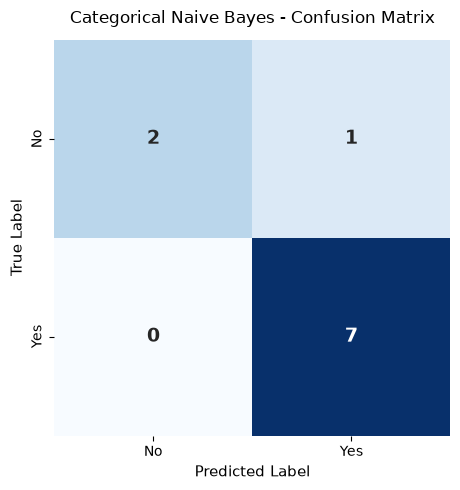

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_cnb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=target_encoder.classes_, 
    yticklabels=target_encoder.classes_,
    cbar=False,
    square=True,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Categorical Naive Bayes - Confusion Matrix', fontsize=12, pad=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42)

dt.fit(X_train, y_train)
lr.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_lr = lr.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_lr = accuracy_score(y_test, y_pred_lr)

pred_dt = target_encoder.inverse_transform(dt.predict(sample_encoded))[0]
prob_dt = dt.predict_proba(sample_encoded)[0]

pred_lr = target_encoder.inverse_transform(lr.predict(sample_encoded))[0]
prob_lr = lr.predict_proba(sample_encoded)[0]

comparison_df = pd.DataFrame({
    'Model': ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [f"{acc_cnb*100:.2f}%", f"{acc_dt*100:.2f}%", f"{acc_lr*100:.2f}%"],
    'Query Prediction': [
        target_encoder.inverse_transform([pred_class_cnb])[0],
        pred_dt,
        pred_lr
    ],
    'P(No)': [f"{pred_prob_cnb[0]:.4f}", f"{prob_dt[0]:.4f}", f"{prob_lr[0]:.4f}"],
    'P(Yes)': [f"{pred_prob_cnb[1]:.4f}", f"{prob_dt[1]:.4f}", f"{prob_lr[1]:.4f}"]
})

print("Model Performance & Prediction Comparison")
comparison_df

Model Performance & Prediction Comparison


,Model,Accuracy,Query Prediction,P(No),P(Yes)
0,Categorical Naive Bayes,90.00%,No,0.7894,0.2106
1,Decision Tree,100.00%,No,1.0000,0.0000
2,Logistic Regression,90.00%,No,0.8613,0.1387


* **Categorical Naive Bayes** naturally handles categorical features with discrete distributions, making it well-suited for tabular categorical data like the Play Tennis dataset.
* **Decision Trees** split features greedily and can memorize rules easily; on small datasets, it often achieves high accuracy but may overfit without pruning.
* **Logistic Regression** assumes ordinal relationships when using simple ordinal integer encoding; for better Logistic Regression results on purely nominal variables, One-Hot Encoding is often preferred.